<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/dataExploring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data


Load the dataset from '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt' into a pandas DataFrame.


In [1]:
print('test colab & git')

test colab & git


In [ ]:
datasetPath = '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt'

In [ ]:
Farm_Code,  Animal_ID     ,        dtb,        dtc,        dtt,    parity,   milk_kg,    fat_p,   protein_p,    cells,    NM
0521513  ,  IT003990129052,     [null],     [null],   20220918,  20230125,         3,       38,         635,      444,  308,  2
0521513  ,  IT003990129052,     [null],     [null],   20220918,  20230125,         3,       38,         635,      444,  308,  2
0521513  ,  IT003990135425,   20170902,   20221208,   20230125,         3,       184,      694,         374,       45,    2
0521513  ,  IT003990065238,   20110413,   20210825,   20220216,         3,        87,      737,         465,      928,    2



In [ ]:
import pandas as pd

# 1. Define your column names
col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

# 2. Read and clean the file line by line
with open(datasetPath, 'r') as file:
    # Skip the header line
    next(file)

    for line in file:
        # Remove whitespace/newlines from ends
        line = line.strip()

        # Skip empty lines if any exist
        if not line:
            continue

        # Split the line by comma
        parts = line.split(',')

        # LOGIC: Fix the rows based on length
        if len(parts) == 11:
            # This is a correct row, keep it as is
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            # This is a broken row.
            # This leaves one empty slot for 'dtb' and shifts the rest back.
            parts.pop(2)
            cleaned_rows.append(parts)

# 3. Create the DataFrame
df = pd.DataFrame(cleaned_rows, columns=col_names)

# 4. Convert columns to correct types (since they were read as strings)
numeric_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Convert Date Columns
date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce')

# Check the result
print(df.head())
print(f"\nTotal rows loaded: {len(df)}")

  Farm_Code       Animal_ID        dtb        dtc        dtt  parity  milk_kg  \
0   0521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6      141   
1   0521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6      168   
2   0521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6      134   
3   0521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6      108   
4   0521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6       94   

   fat_p  protein_p  cells  NM  
0    617        484    656   2  
1    682        417    827   2  
2    763        459   1144   2  
3    663        454   1403   2  
4    688        451   1805   2  

Total rows loaded: 2593267


In [ ]:
df.isnull().sum()

,0
Farm_Code,0
Animal_ID,0
dtb,1873
dtc,0
dtt,0
parity,0
milk_kg,0
fat_p,0
protein_p,0
cells,0


In [ ]:
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,NM
count,2591394,2593267,2593267,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06
mean,2013-01-15 01:02:46.180518656,2019-02-12 07:56:07.435903232,2019-07-08 02:21:46.675169536,3.379940e+00,9.043340e+01,7.788952e+02,4.567361e+02,2.811822e+02,1.973870e+00
min,1985-07-01 00:00:00,2011-05-09 00:00:00,2013-01-02 00:00:00,1.000000e+00,0.000000e+00,-3.870000e+02,-2.370000e+02,0.000000e+00,1.000000e+00
25%,2010-01-23 00:00:00,2016-05-11 00:00:00,2016-10-11 00:00:00,1.000000e+00,6.500000e+01,6.720000e+02,4.390000e+02,4.300000e+01,2.000000e+00
50%,2013-03-13 00:00:00,2019-11-02 00:00:00,2020-03-09 00:00:00,3.000000e+00,8.700000e+01,7.960000e+02,4.670000e+02,9.600000e+01,2.000000e+00
75%,2016-07-06 00:00:00,2021-11-25 00:00:00,2022-04-04 00:00:00,5.000000e+00,1.140000e+02,9.150000e+02,4.980000e+02,2.390000e+02,2.000000e+00
max,2021-12-29 00:00:00,2023-12-24 00:00:00,2023-12-29 00:00:00,2.700000e+01,8.860000e+02,7.943000e+03,8.557000e+03,9.814700e+04,3.000000e+00
std,NaN,NaN,NaN,2.437515e+00,3.808888e+01,2.387913e+02,9.352945e+01,7.981789e+02,1.717433e-01


Generating data visualizations for numerical columns...


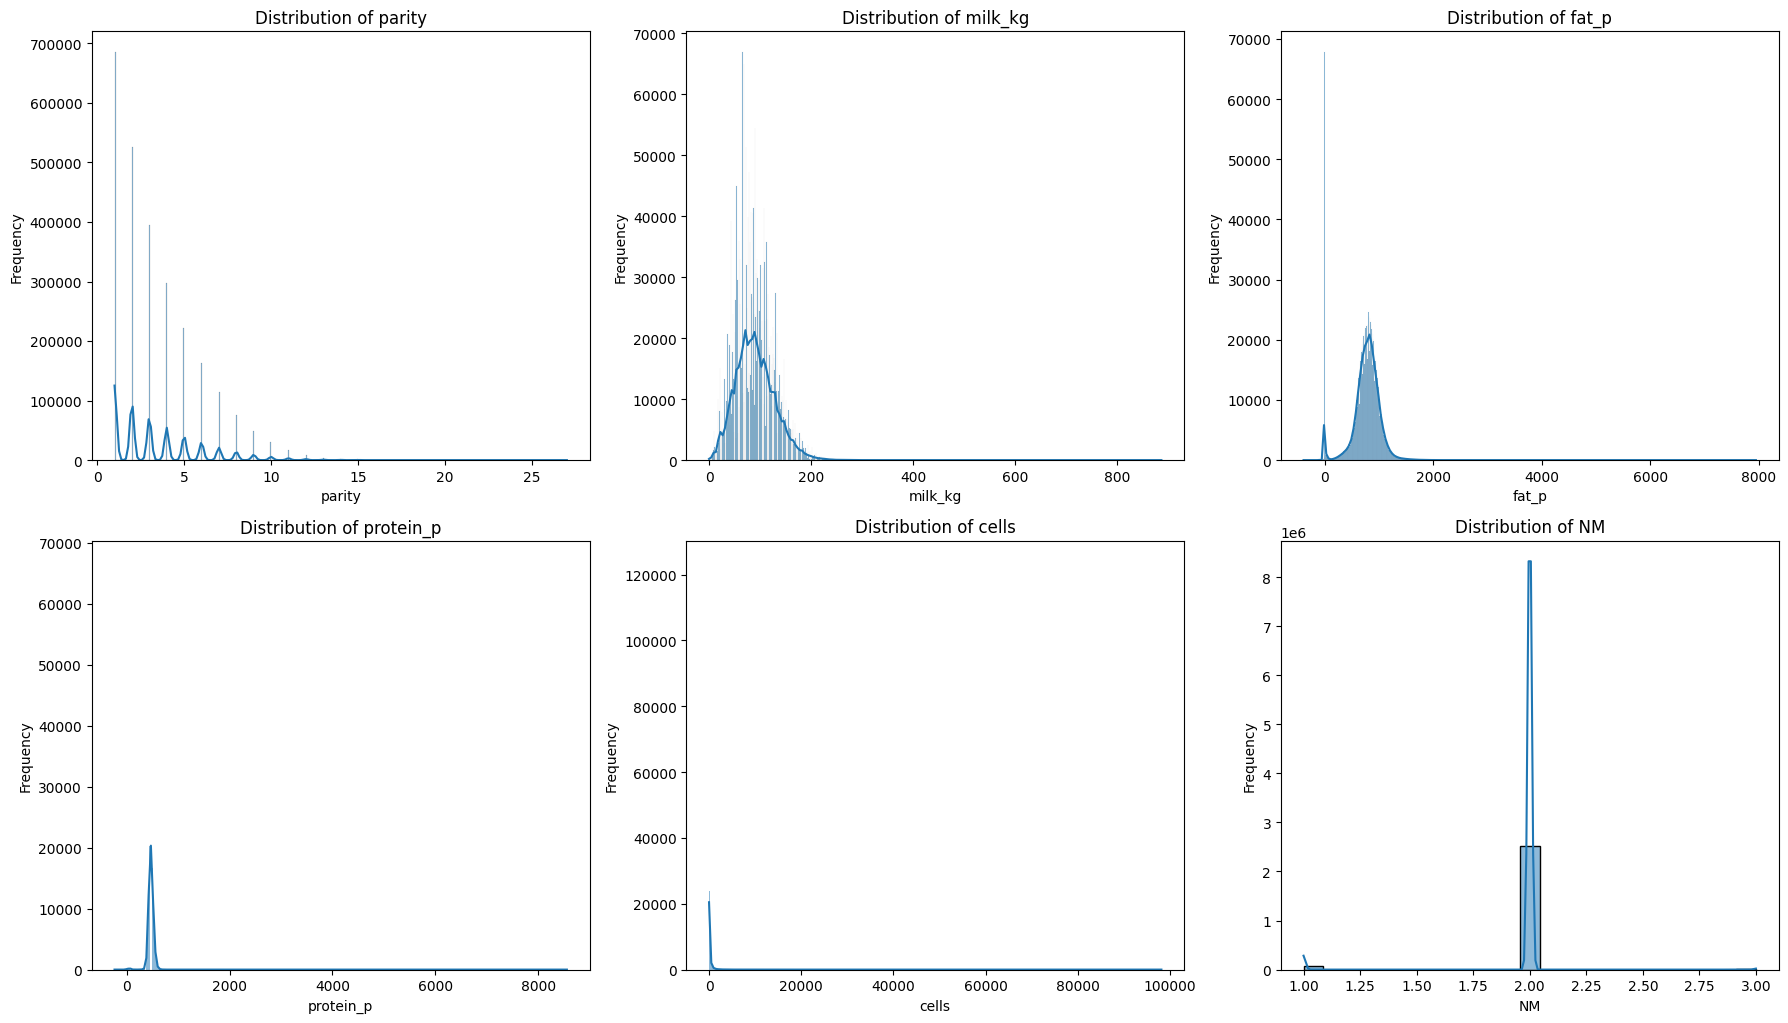

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating data visualizations for numerical columns...")

# Set up the matplotlib figure and axes for subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

# Select numerical columns for visualization, excluding date-like integers and IDs
numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create histograms for numerical columns
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### parity

In [ ]:
df['parity'].quantile([0.01,0.99])

,parity
0.01,1.0
0.99,11.0


In [ ]:
len(df[(df['parity'] > 11) | (df['parity'] < 1)])

17819

### milk_kg

In [ ]:
df['milk_kg'].quantile([0.01,0.99])

,milk_kg
0.01,18.0
0.99,193.0


In [ ]:
len(df[(df['milk_kg'] > 193) | (df['milk_kg'] < 18)])

48143

### fat_p


In [ ]:
len(df[df['fat_p']==0])

67455

In [ ]:
df['fat_p'].quantile([0.03,0.99])

,fat_p
0.03,36.0
0.99,1327.0


In [ ]:
len(df[(df['fat_p'] > 1327) | (df['fat_p'] < 36)])

103640

### protein_p

In [ ]:
len(df[df['protein_p']==0])

66973

In [ ]:
df['protein_p'].quantile([0.03,0.99])

,protein_p
0.03,63.0
0.99,588.0


In [ ]:
len(df[(df['protein_p'] > 588) | (df['protein_p'] < 63)])

103271

### cells

In [ ]:
len(df[df['cells']==0])

118300

In [ ]:
df['cells'].quantile([0.05,0.99])

,cells
0.05,4.0
0.99,3081.0


In [ ]:
len(df[(df['cells'] > 3081) | (df['cells'] < 4)])

152612

### NM

In [ ]:
df['NM'].quantile([0.01,0.99])

,NM
0.01,1.0
0.99,2.0


In [ ]:
len(df[(df['NM'] > 2) | (df['NM'] < 1)])

5249